# 🚦 Traffic Accident Hotspot Analyzer
## Notebook 01 — Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset deeply before clustering and prediction.

### What we cover:
1. Load & inspect dataset
2. Data cleaning (missing values, types, duplicates)
3. Feature engineering (hour, day, month, season)
4. Univariate analysis (severity, time, weather)
5. Bivariate analysis (severity vs weather, time vs severity)
6. Geospatial quick look
7. Save cleaned dataset for next notebooks

---
## 1. Imports & Config

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']
sns.set_palette(PALETTE)

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_PATH   = '/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv'
OUTPUT_DIR  = '../data/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Imports done')

✅ Imports done


---
## 2. Load Dataset

In [24]:
# Load with only the columns we actually need — saves RAM on a 3M row file
COLS = [
    'ID', 'Severity', 'Start_Time', 'End_Time',
    'Start_Lat', 'Start_Lng',
    'City', 'County', 'State', 'Zipcode',
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Sunrise_Sunset',
    'Junction', 'Traffic_Signal', 'Crossing'
]

df = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

print(f'Shape          : {df.shape}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape          : (7728394, 20)
Memory usage   : 4580.7 MB


,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Zipcode,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Crossing,Junction,Traffic_Signal,Sunrise_Sunset
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,45424,36.9,91.0,10.0,NaN,0.02,Light Rain,False,False,False,Night
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,43068-3402,37.9,100.0,10.0,NaN,0.00,Light Rain,False,False,False,Night
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,45176,36.0,100.0,10.0,3.5,NaN,Overcast,False,False,True,Night


In [25]:
# Quick schema overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 20 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ID                 object 
 1   Severity           int64  
 2   Start_Time         object 
 3   End_Time           object 
 4   Start_Lat          float64
 5   Start_Lng          float64
 6   City               object 
 7   County             object 
 8   State              object 
 9   Zipcode            object 
 10  Temperature(F)     float64
 11  Humidity(%)        float64
 12  Visibility(mi)     float64
 13  Wind_Speed(mph)    float64
 14  Precipitation(in)  float64
 15  Weather_Condition  object 
 16  Crossing           bool   
 17  Junction           bool   
 18  Traffic_Signal     bool   
 19  Sunrise_Sunset     object 
dtypes: bool(3), float64(7), int64(1), object(9)
memory usage: 1.0+ GB


---
## 3. Data Cleaning

Columns with missing values:


,count,pct
Precipitation(in),2203586,28.51
Wind_Speed(mph),571233,7.39
Visibility(mi),177098,2.29
Humidity(%),174144,2.25
Weather_Condition,173459,2.24
Temperature(F),163853,2.12
Sunrise_Sunset,23246,0.30
Zipcode,1915,0.02
City,253,0.00


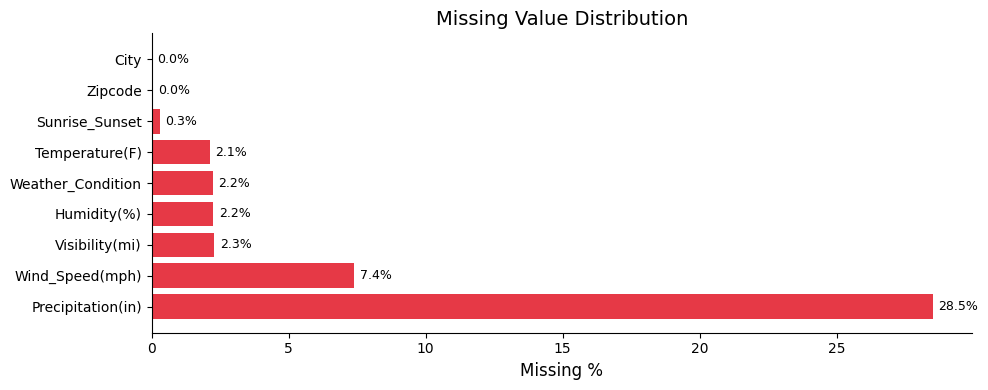

In [26]:
# ── 3.1 Missing value audit ──────────────────────────────────────────────────
missing = (
    df.isnull().sum()
      .rename('count')
      .to_frame()
)
missing['pct'] = (missing['count'] / len(df) * 100).round(2)
missing = missing[missing['count'] > 0].sort_values('pct', ascending=False)

print('Columns with missing values:')
display(missing)

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing.index, missing['pct'], color='#e63946')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Distribution')
for i, v in enumerate(missing['pct']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
# ── 3.2 Drop rows with missing critical columns ──────────────────────────────
before = len(df)
df.dropna(subset=['Start_Lat', 'Start_Lng', 'Severity', 'Start_Time'], inplace=True)
print(f'Dropped {before - len(df):,} rows missing critical fields. Remaining: {len(df):,}')

# ── 3.3 Fill numeric columns with median (robust to outliers) ────────────────
num_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
            'Wind_Speed(mph)', 'Precipitation(in)']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# ── 3.4 Fill categoricals with mode ─────────────────────────────────────────
df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0], inplace=True)
df['Sunrise_Sunset'].fillna('Day', inplace=True)

# ── 3.5 Remove duplicates ────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['ID'], inplace=True)
print(f'Dropped {before - len(df):,} duplicate rows.')

print(f'\n✅ Clean dataset shape: {df.shape}')

Dropped 0 rows missing critical fields. Remaining: 7,728,394
Dropped 0 duplicate rows.

✅ Clean dataset shape: (7728394, 20)


---
## 4. Feature Engineering

In [28]:
# ── Parse datetime ───────────────────────────────────────────────────────────
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce')
df.dropna(subset=['Start_Time'], inplace=True)

# ── Time features ────────────────────────────────────────────────────────────
df['Hour']       = df['Start_Time'].dt.hour
df['DayOfWeek']  = df['Start_Time'].dt.day_name()      # Monday … Sunday
df['Month']      = df['Start_Time'].dt.month
df['MonthName']  = df['Start_Time'].dt.month_name()
df['Year']       = df['Start_Time'].dt.year
df['IsWeekend']  = df['Start_Time'].dt.dayofweek >= 5  # True = Sat/Sun

# ── Duration in minutes ──────────────────────────────────────────────────────
df['Duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
# Clip unreasonable durations (negative or > 24h)
df['Duration_min'] = df['Duration_min'].clip(lower=0, upper=1440)

# ── Season ───────────────────────────────────────────────────────────────────
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                    return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# ── Time-of-day buckets ──────────────────────────────────────────────────────
def time_of_day(hour):
    if 5  <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:                 return 'Night'

df['TimeOfDay'] = df['Hour'].apply(time_of_day)

# ── Broad weather groups ─────────────────────────────────────────────────────
def weather_group(w):
    w = str(w).lower()
    if any(k in w for k in ['rain', 'drizzle', 'shower']):   return 'Rain'
    if any(k in w for k in ['snow', 'sleet', 'blizzard']):   return 'Snow/Ice'
    if any(k in w for k in ['fog', 'mist', 'haze']):         return 'Fog/Mist'
    if any(k in w for k in ['thunder', 'storm']):             return 'Thunderstorm'
    if any(k in w for k in ['clear', 'fair']):                return 'Clear'
    if any(k in w for k in ['cloud', 'overcast']):            return 'Cloudy'
    return 'Other'

df['WeatherGroup'] = df['Weather_Condition'].apply(weather_group)

print('✅ Feature engineering done')
df[['Hour', 'DayOfWeek', 'Season', 'TimeOfDay', 'WeatherGroup', 'Duration_min']].head()

✅ Feature engineering done


,Hour,DayOfWeek,Season,TimeOfDay,WeatherGroup,Duration_min
0,5,Monday,Winter,Morning,Rain,314.0
1,6,Monday,Winter,Morning,Rain,30.0
2,6,Monday,Winter,Morning,Cloudy,30.0
3,7,Monday,Winter,Morning,Cloudy,30.0
4,7,Monday,Winter,Morning,Cloudy,30.0


---
## 5. Univariate Analysis

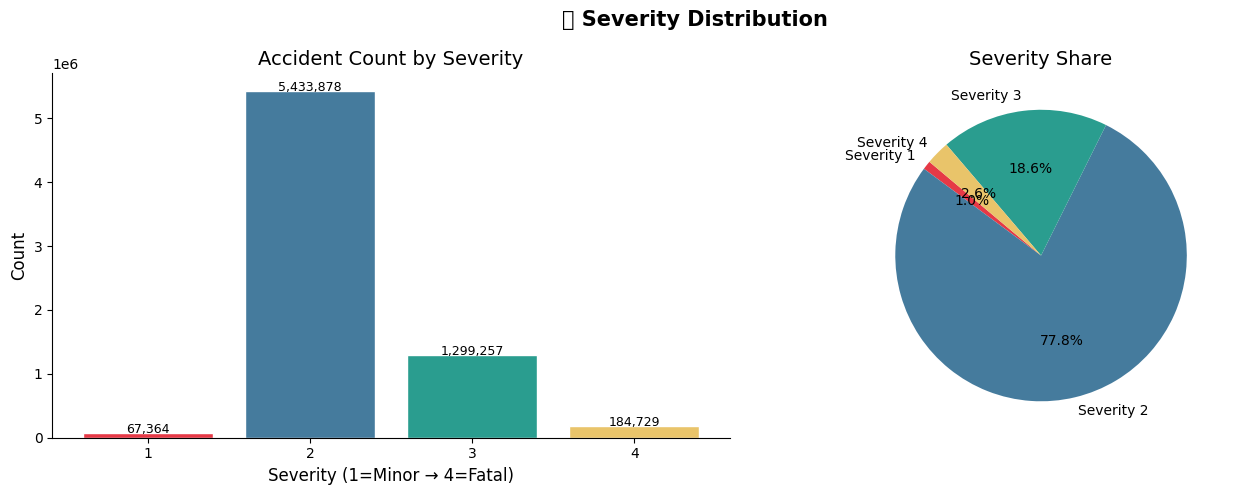

Severity
1      67364
2    5433878
3    1299257
4     184729


In [29]:
# ── 5.1 Severity Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sev_counts = df['Severity'].value_counts().sort_index()
axes[0].bar(sev_counts.index.astype(str), sev_counts.values,
            color=PALETTE[:4], edgecolor='white')
axes[0].set_title('Accident Count by Severity')
axes[0].set_xlabel('Severity (1=Minor → 4=Fatal)')
axes[0].set_ylabel('Count')
for i, v in enumerate(sev_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(sev_counts.values,
            labels=[f'Severity {s}' for s in sev_counts.index],
            colors=PALETTE[:4], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Severity Share')

plt.suptitle('🔴 Severity Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(sev_counts.to_string())

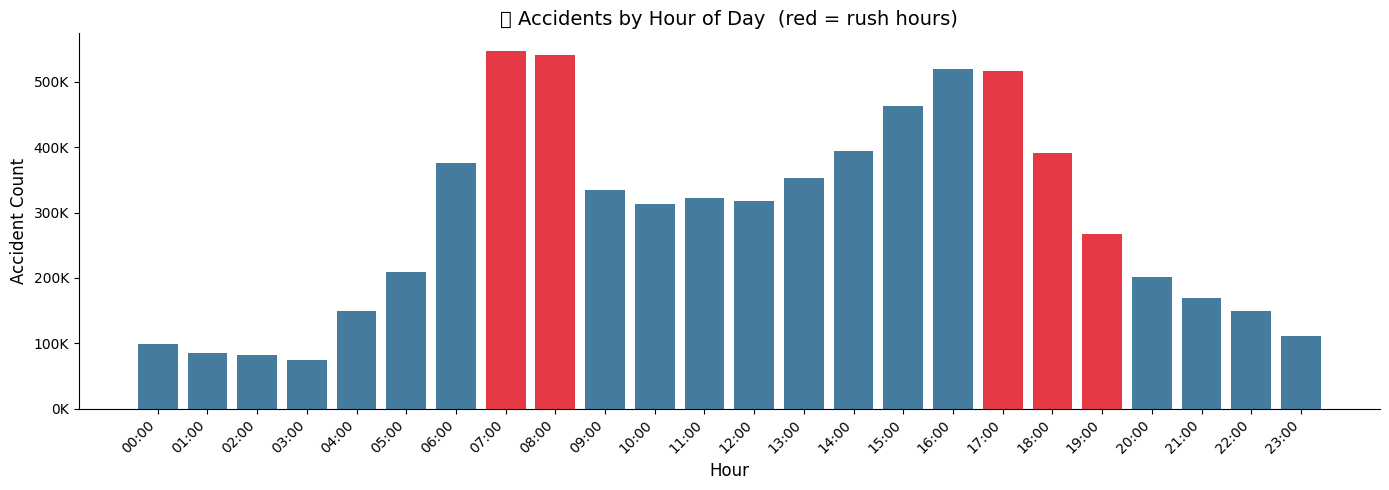

In [30]:
# ── 5.2 Accidents by Hour ────────────────────────────────────────────────────
hourly = df.groupby('Hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(hourly['Hour'], hourly['count'],
              color=['#e63946' if h in [7,8,17,18,19] else '#457b9d'
                     for h in hourly['Hour']])
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_title('⏰ Accidents by Hour of Day  (red = rush hours)', fontsize=14)
ax.set_xlabel('Hour')
ax.set_ylabel('Accident Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

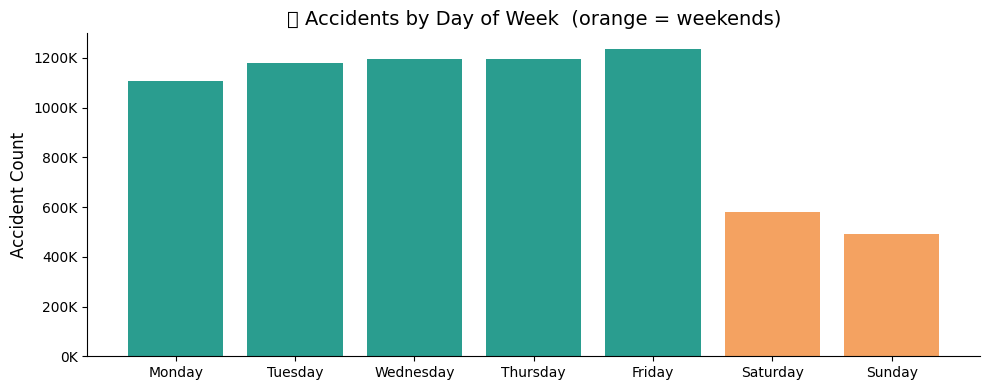

In [31]:
# ── 5.3 Accidents by Day of Week ─────────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['DayOfWeek'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(daily.index, daily.values,
       color=['#f4a261' if d in ['Saturday','Sunday'] else '#2a9d8f' for d in daily.index])
ax.set_title('📅 Accidents by Day of Week  (orange = weekends)')
ax.set_ylabel('Accident Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

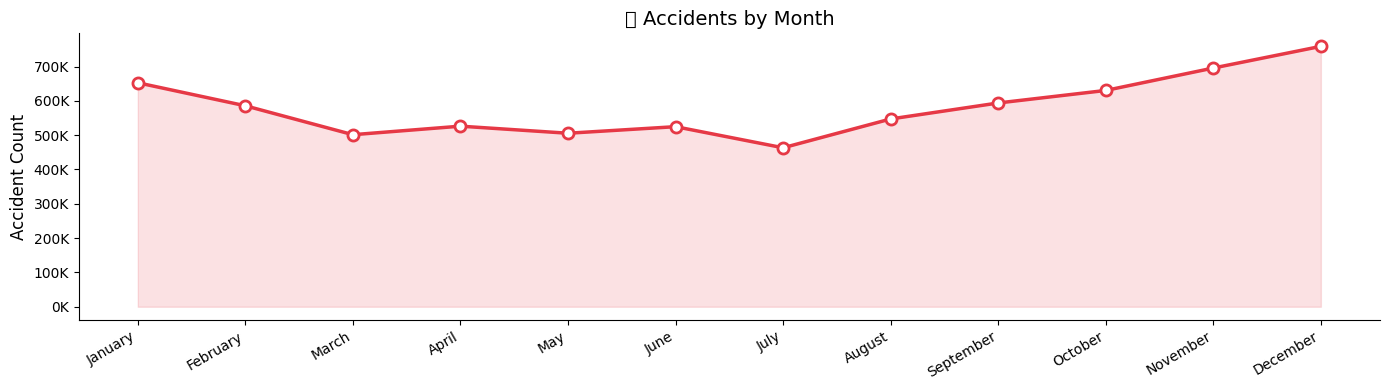

In [32]:
# ── 5.4 Accidents by Month ───────────────────────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df['MonthName'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5,
        color='#e63946', markerfacecolor='white', markeredgewidth=2, markersize=8)
ax.fill_between(range(12), monthly.values, alpha=0.15, color='#e63946')
ax.set_xticks(range(12))
ax.set_xticklabels(month_order, rotation=30, ha='right')
ax.set_title('📆 Accidents by Month')
ax.set_ylabel('Accident Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

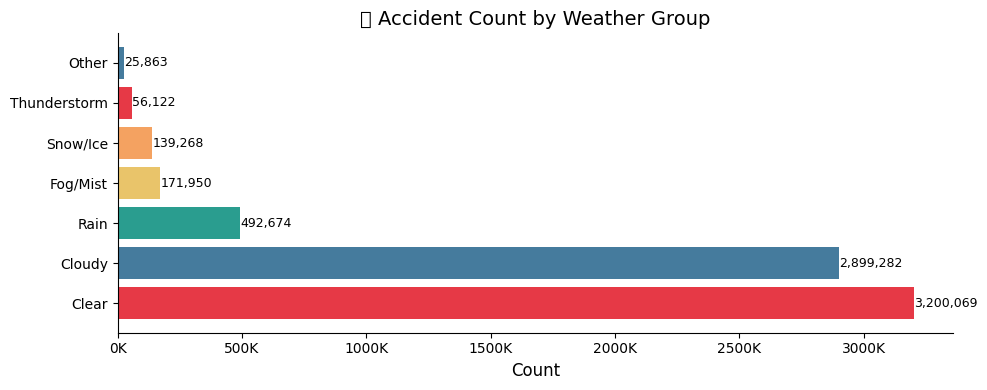

In [33]:
# ── 5.5 Weather Group Distribution ───────────────────────────────────────────
wg = df['WeatherGroup'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(wg.index, wg.values, color=PALETTE)
ax.set_title('🌦 Accident Count by Weather Group')
ax.set_xlabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for i, v in enumerate(wg.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

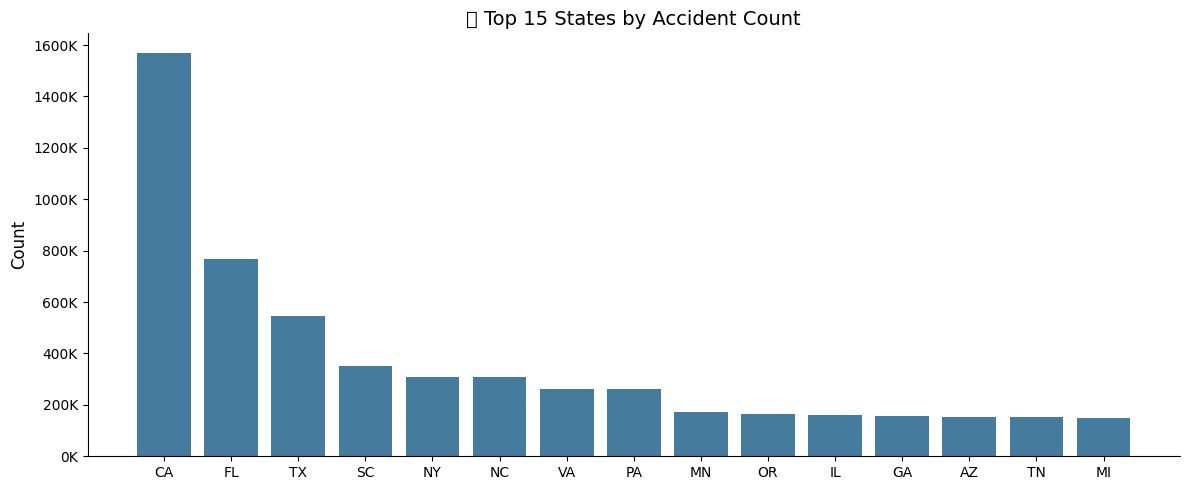

In [34]:
# ── 5.6 Top 15 States ────────────────────────────────────────────────────────
top_states = df['State'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_states.index, top_states.values, color='#457b9d')
ax.set_title('🗺 Top 15 States by Accident Count')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

---
## 6. Bivariate Analysis

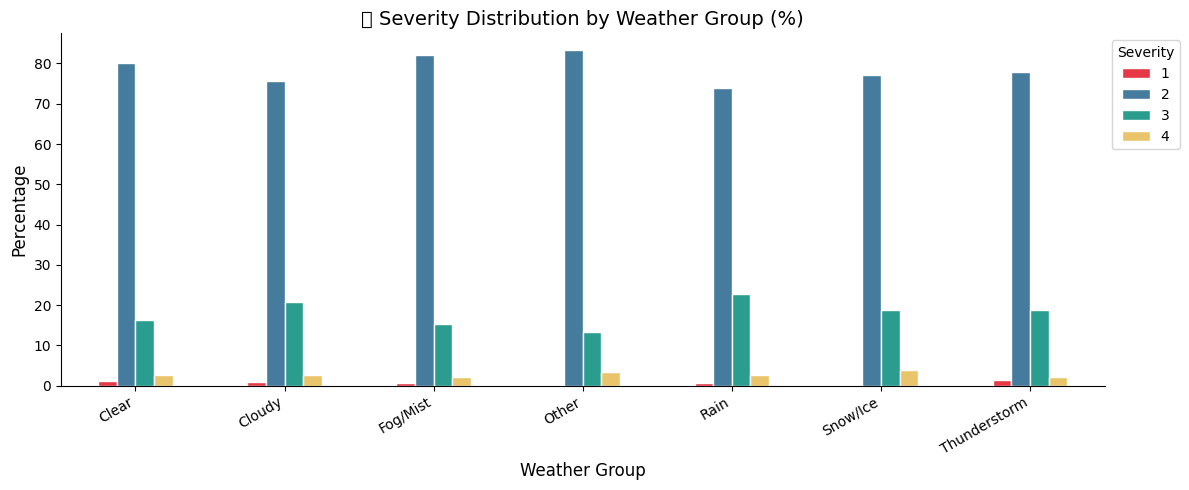

In [35]:
# ── 6.1 Severity vs Weather Group ────────────────────────────────────────────
sev_weather = (
    df.groupby(['WeatherGroup', 'Severity'])
      .size()
      .unstack(fill_value=0)
)

# Normalise to percentage per weather group
sev_weather_pct = sev_weather.div(sev_weather.sum(axis=1), axis=0) * 100

ax = sev_weather_pct.plot(kind='bar', figsize=(12, 5),
                           color=PALETTE[:4], edgecolor='white')
ax.set_title('🌦 Severity Distribution by Weather Group (%)')
ax.set_xlabel('Weather Group')
ax.set_ylabel('Percentage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Severity', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

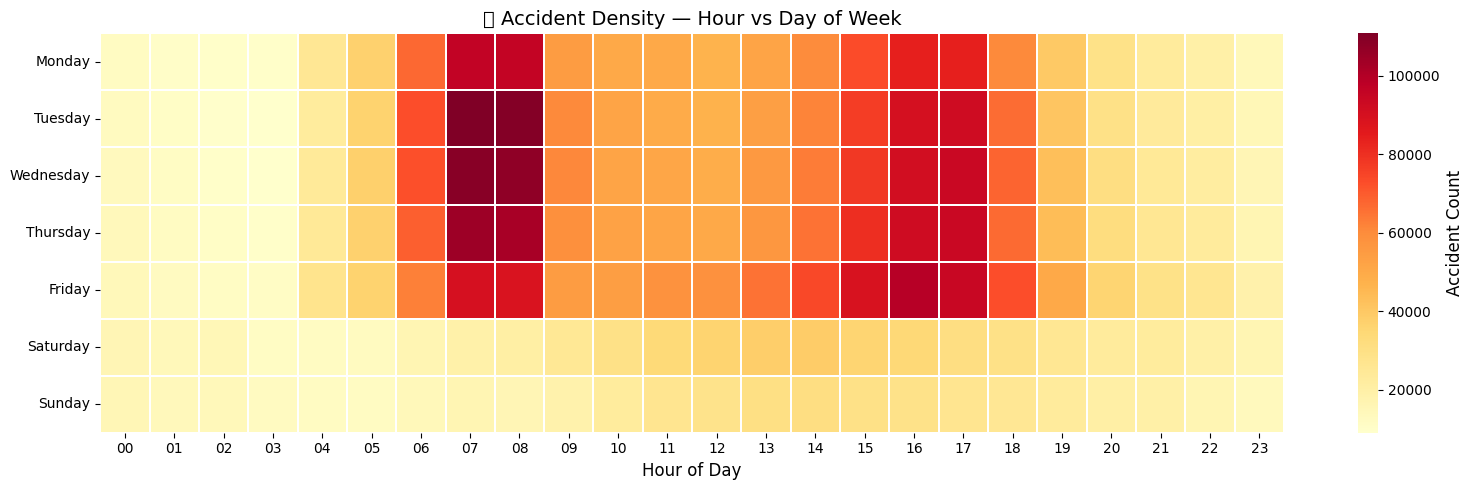

In [36]:
# ── 6.2 Heatmap — Hour × Day of Week (accident density) ─────────────────────
pivot = (
    df.groupby(['DayOfWeek', 'Hour'])
      .size()
      .unstack()
      .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            ax=ax, fmt='.0f',
            cbar_kws={'label': 'Accident Count'})
ax.set_title('🔥 Accident Density — Hour vs Day of Week', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
plt.tight_layout()
plt.show()

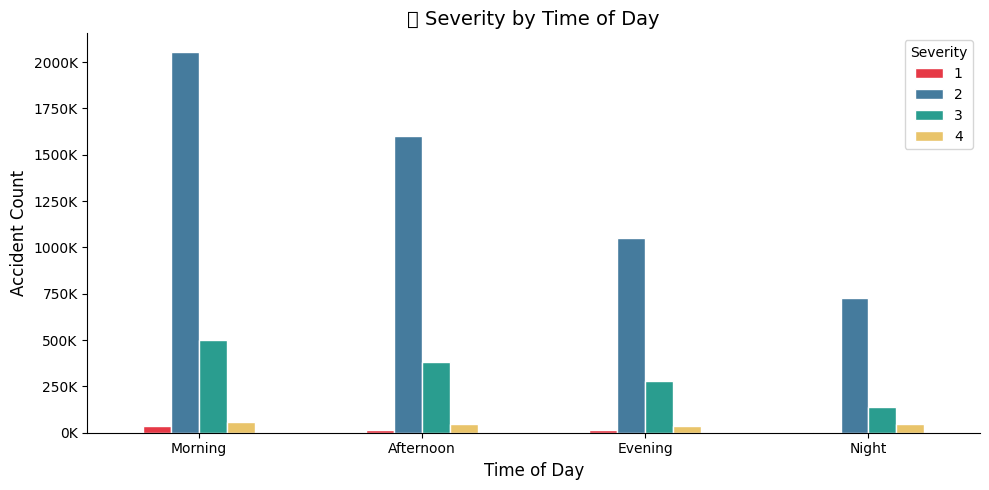

In [37]:
# ── 6.3 Severity vs Time of Day ───────────────────────────────────────────────
tod_sev = (
    df.groupby(['TimeOfDay', 'Severity'])
      .size()
      .unstack(fill_value=0)
)
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_sev = tod_sev.reindex(tod_order)

ax = tod_sev.plot(kind='bar', figsize=(10, 5),
                  color=PALETTE[:4], edgecolor='white')
ax.set_title('⏰ Severity by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Accident Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Severity')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

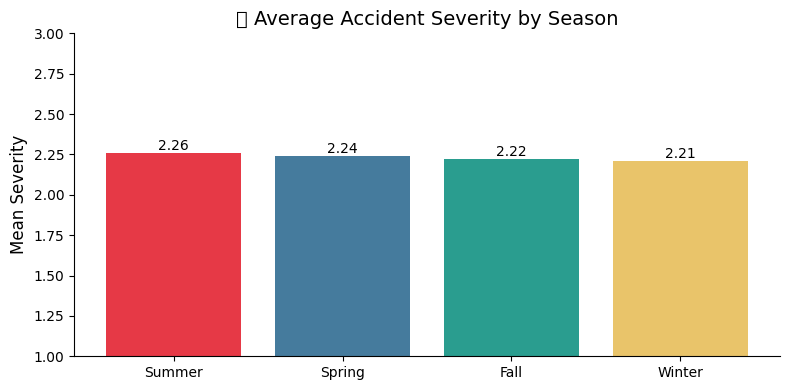

In [38]:
# ── 6.4 Average Severity by Season ───────────────────────────────────────────
season_sev = df.groupby('Season')['Severity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(season_sev.index, season_sev.values, color=PALETTE)
ax.set_title('🍂 Average Accident Severity by Season')
ax.set_ylabel('Mean Severity')
ax.set_ylim(1, 3)
for i, v in enumerate(season_sev.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

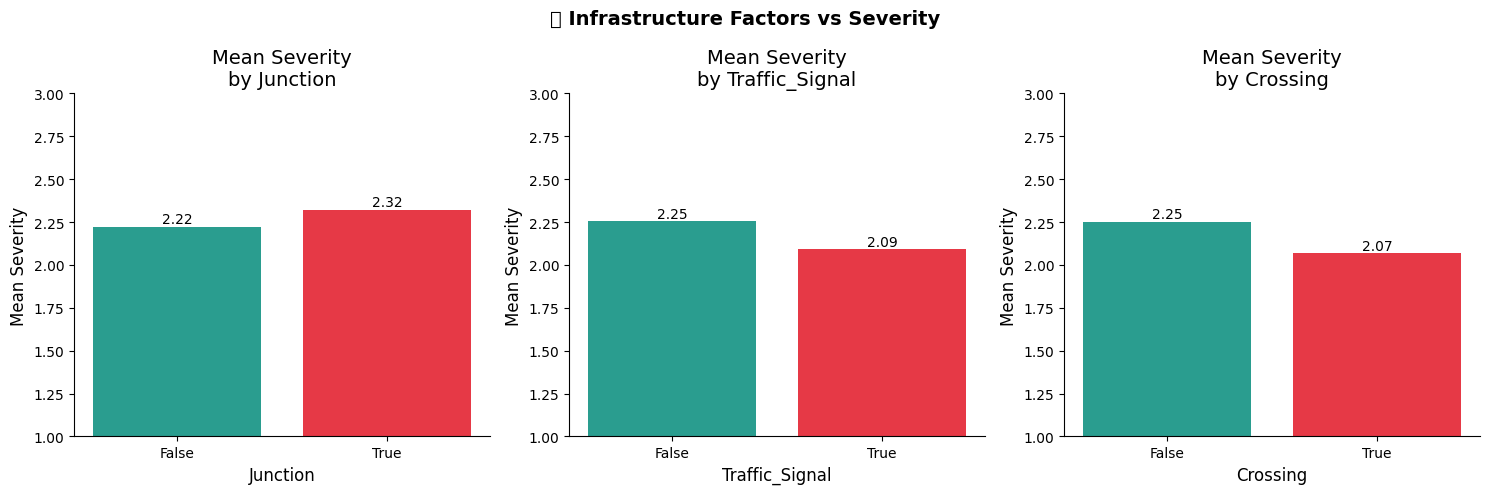

In [39]:
# ── 6.5 Infrastructure factors vs Severity ───────────────────────────────────
infra_cols = ['Junction', 'Traffic_Signal', 'Crossing']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, col in zip(axes, infra_cols):
    grp = df.groupby(col)['Severity'].mean()
    ax.bar([str(k) for k in grp.index], grp.values, color=['#2a9d8f', '#e63946'])
    ax.set_title(f'Mean Severity\nby {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Mean Severity')
    ax.set_ylim(1, 3)
    for i, v in enumerate(grp.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.suptitle('🚦 Infrastructure Factors vs Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

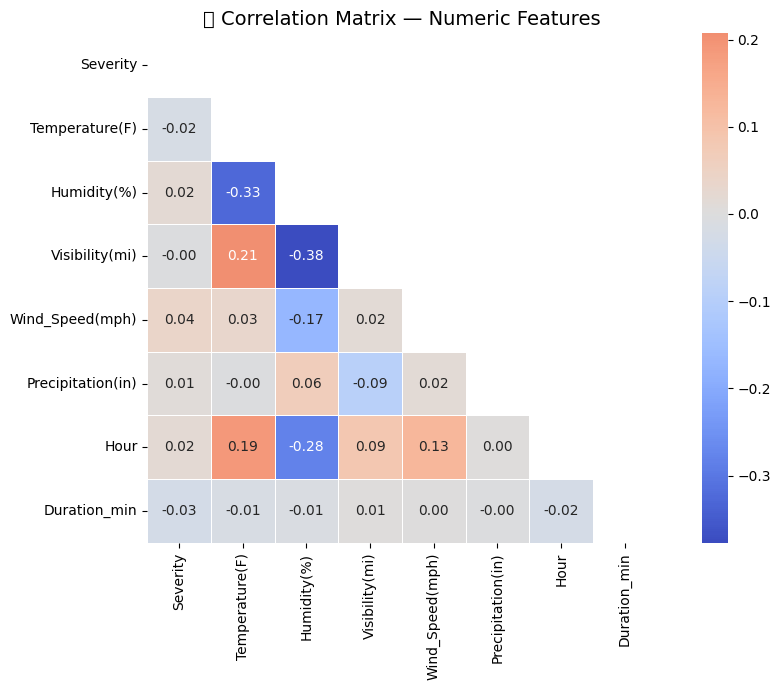

In [40]:
# ── 6.6 Correlation heatmap (numeric features) ───────────────────────────────
num_features = [
    'Severity', 'Temperature(F)', 'Humidity(%)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Hour', 'Duration_min'
]

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, square=True)
ax.set_title('📊 Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

---
## 7. Geospatial Quick Look

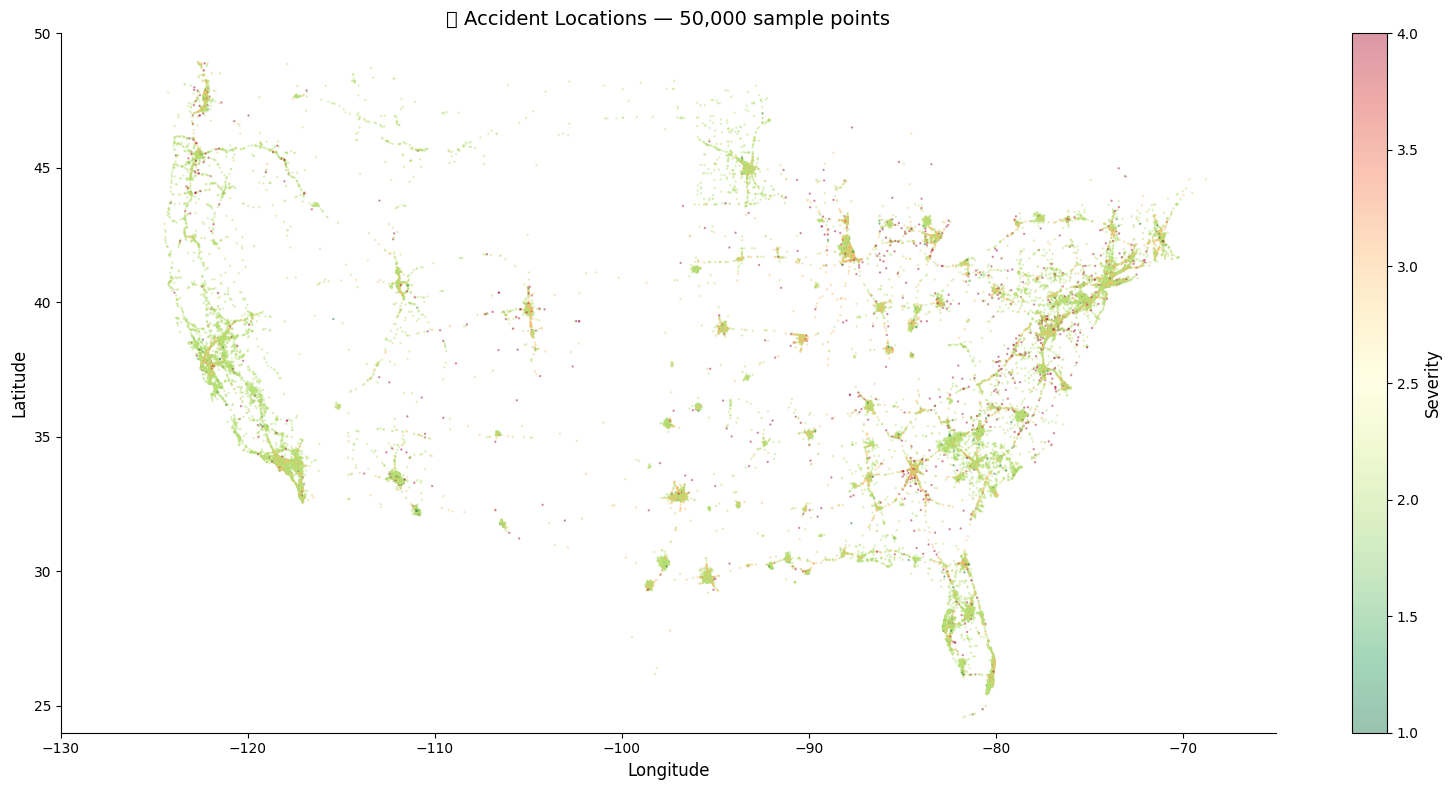

In [41]:
# Sample 50k points for the scatter plot (plotting all 3M is slow)
SAMPLE_N = 50_000
df_sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(16, 8))
scatter = ax.scatter(
    df_sample['Start_Lng'],
    df_sample['Start_Lat'],
    c=df_sample['Severity'],
    cmap='RdYlGn_r',
    s=0.5,
    alpha=0.4
)
plt.colorbar(scatter, ax=ax, label='Severity')
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)
ax.set_title(f'🗺 Accident Locations — {SAMPLE_N:,} sample points', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

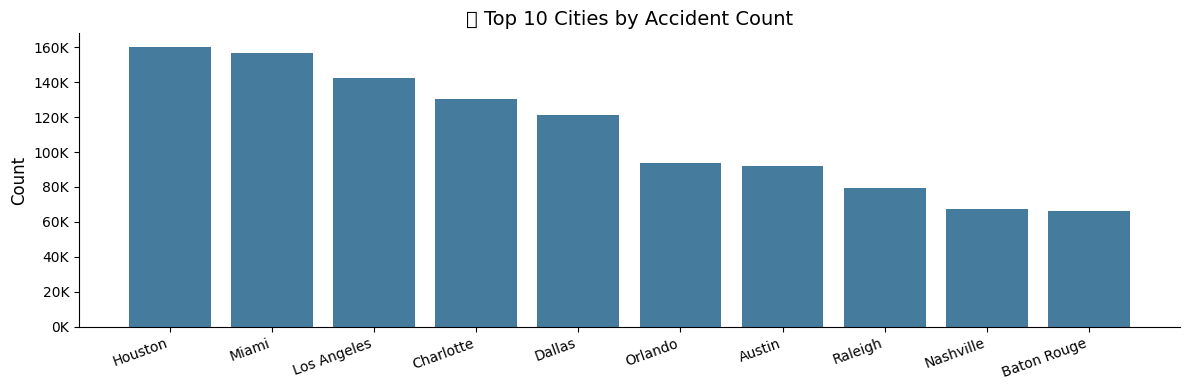

In [42]:
# Top 10 cities by accident count
top_cities = df['City'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top_cities.index, top_cities.values, color='#457b9d')
ax.set_title('🏙 Top 10 Cities by Accident Count')
ax.set_ylabel('Count')
ax.set_xticklabels(top_cities.index, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

---
## 8. Key Insights Summary

In [43]:
print('=' * 60)
print('  📋 EDA KEY INSIGHTS SUMMARY')
print('=' * 60)

print(f"\n📦 Dataset size      : {len(df):,} records after cleaning")
print(f"📅 Year range        : {df['Year'].min()} – {df['Year'].max()}")

top_sev = df['Severity'].value_counts(normalize=True).idxmax()
print(f"⚠️  Dominant severity : Severity {top_sev} "
      f"({df['Severity'].value_counts(normalize=True).max()*100:.1f}%)")

peak_hour = hourly.loc[hourly['count'].idxmax(), 'Hour']
print(f"⏰ Peak accident hour : {peak_hour:02d}:00")

peak_day = daily.idxmax()
print(f"📅 Busiest day        : {peak_day}")

peak_weather = df['WeatherGroup'].value_counts().idxmax()
print(f"🌦 Most common weather: {peak_weather}")

top_state = df['State'].value_counts().idxmax()
print(f"🗺  Highest-risk state : {top_state}")

print(f"\n⏩ Next step → 02_clustering.ipynb")
print('=' * 60)

  📋 EDA KEY INSIGHTS SUMMARY

📦 Dataset size      : 6,985,228 records after cleaning
📅 Year range        : 2016 – 2023
⚠️  Dominant severity : Severity 2 (77.8%)
⏰ Peak accident hour : 07:00
📅 Busiest day        : Friday
🌦 Most common weather: Clear
🗺  Highest-risk state : CA

⏩ Next step → 02_clustering.ipynb


---
## 9. Save Cleaned Dataset

In [48]:
SAVE_PATH = "accidents_clean.parquet"

# Save as parquet — 10x faster to read than CSV, much smaller
df.to_parquet(SAVE_PATH, index=False)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'✅ Saved cleaned dataset to: {SAVE_PATH}')
print(f'   Rows     : {len(df):,}')
print(f'   Columns  : {len(df.columns)}')
print(f'   File size: {size_mb:.1f} MB')
print()
print('🚀 Ready for → 02_clustering.ipynb')

✅ Saved cleaned dataset to: accidents_clean.parquet
   Rows     : 6,985,228
   Columns  : 30
   File size: 360.7 MB

🚀 Ready for → 02_clustering.ipynb
